In [16]:
import pandas as pd

data = pd.read_csv("gap.tsv", sep='\t')

data.head()

df = pd.DataFrame(data) # Create a DataFrame

**Exercise 1**: *Make a scatter plot of life expectancy across time.*



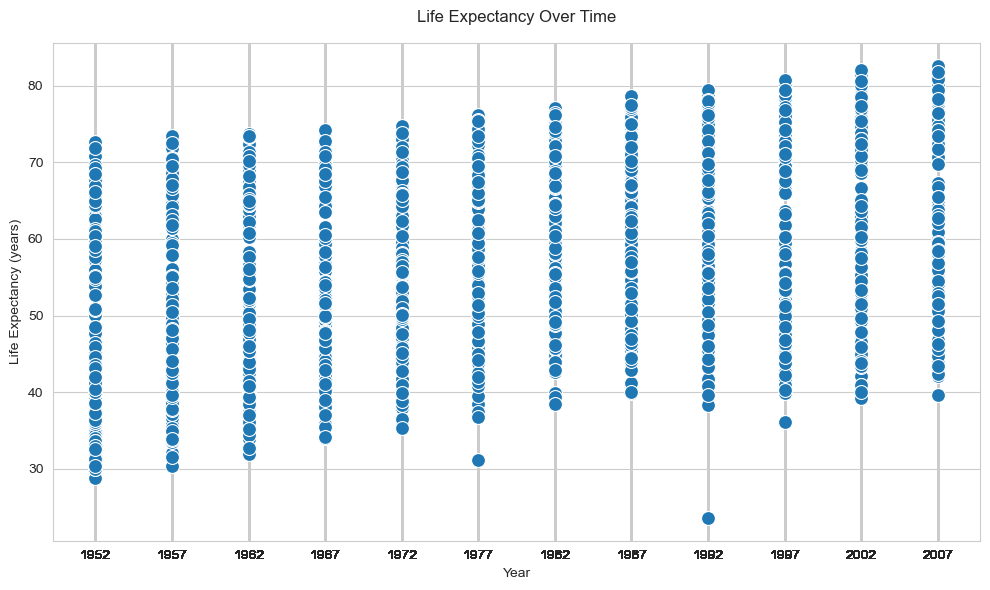

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(data=data, 
                x='year', 
                y='lifeExp',
                s=100,  # Marker size
                color='#1f77b4')  # blue color

# Add a regression line
# sns.regplot(data=data,
#             x='year',
#             y='lifeExp',
#             scatter=False,  # Don't add more scatter points
#             color='red',
#             line_kws={'linestyle': '--'})

# Customize the plot
plt.title('Life Expectancy Over Time', pad=15)
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')

# Set x-axis ticks to show all years
plt.xticks(data['year'])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

**Question 1** 

<b>Is there a general trend (e.g., increasing or decreasing) for life expectancy across time? Is this trend linear? (answering this qualitatively from the plot, you will do a statistical analysis of this question shortly) </b>

From this scatter plot, we can observe that there is a general upward trend in life expectancy over time, as the values tend to increase slightly from 1950s to 2000s. Although there is a gradual increase in life expectancy, there are few outlier data points with significant variation, which suggest that a this may not be a smooth linear trend.

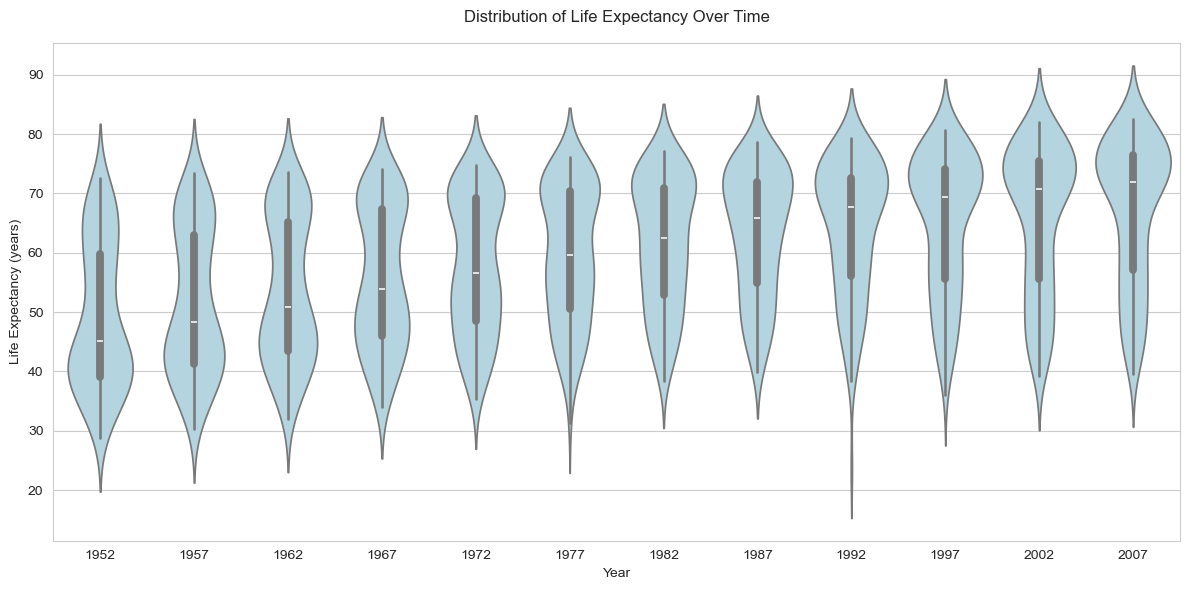

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# For a violin plot, it's better to have more data points per year
# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Create the violin plot
sns.violinplot(data=data,
               x='year',
               y='lifeExp',
               color='lightblue',
               inner='box'  # Show box plot inside violin
               )  # Don't extend beyond observed data

# Customize the plot
plt.title('Distribution of Life Expectancy Over Time', pad=15)
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

**Question 2: How would you describe the distribution of life expectancy across countries for individual years? Is it skewed, or not? Unimodal or not? Symmetric around it’s center?**

Life expectancy distributions across countries show three key characteristics. The data is right-skewed, with more countries clustered at higher life expectancy values and a tail extending toward lower values. Each year's distribution displays unimodality, featuring a single clear peak. The asymmetric shape of these distributions, characterized by a broader upper portion and a longer tail toward lower values, indicates that while most nations enjoy higher life expectancies, a smaller number of countries experience notably lower values.

**Question 3: Suppose I fit a linear regression model of life expectancy vs. year (treating it as a continuous variable), and test for a relationship between year and life expectancy, will you reject the null hypothesis of no relationship?**

Based on the scatter plot shown in the image, I would strongly reject the null hypothesis of no relationship between year and life expectancy due to the following reasons:

1. There is a clear upward trend in life expectancy values from 1952 to 2007, with the overall pattern showing a consistent increase over time.  <br>

2. The mean life expectancy appears to have increased.

**Question 4: What would a violin plot of residuals (errors) from the linear model in Question 3 vs. year look like? (Again, don’t do the analysis yet, answer this intuitively). You would answer this question in the context of the variables in Question 3.**

Looking at the scatter plot of life expectancy over time, I would expect the violin plot of residuals vs. year to show several key patterns:

The residuals would show varying spread across years, with: 

1. Wider spread in earlier years (1952-1967) due to greater variability in life expectancy
2. Relatively consistent spread in middle years (1970s-1990s)
3. Possibly narrower spread in recent years (2000s)

Since the life expectancy increases over time. The violin plot of residuals vs. year would likely show patterns of changing spread over time, suggesting that a simple linear model might capture an overall upward trend but but may not account for deviations in specific years.

**Question 5: According to the assumptions of the linear regression model, what should that violin plot look like? You would answer this question as a general property of the residuals of the linear regression. We are looking to see if the Question 3 model fits the general assumptions.**



According to linear regression model assumptions, the residuals should ideally be normally distributed around zero for each year without any discernible pattern over time. In this case, the violin plot of residuals should appear symmetric and centered at zero for each year with a similar range, indicating constant variance between residuals. If the model is a good fit, we would expect no significant skew or trends in residuals across years, as this would indicate that the linear model effectively captures the relationship between year and life expectancy.

**Exercise 2: Fit a linear regression model for life expectancy vs. year**


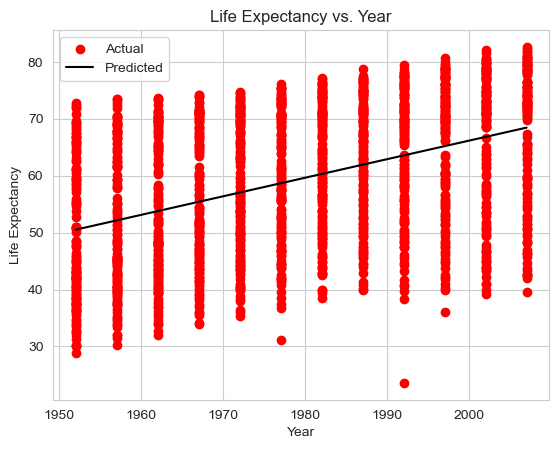

Slope (Average increase in life expectancy per year):  0.3259038276371518
Intercept:  {-585.6521874415448}
R-squared:  {0.18975713852188814}


In [19]:
from sklearn.linear_model import LinearRegression

x = data['year'].values.reshape(-1,1)
y = data['lifeExp']
df=data
linear_model = LinearRegression()
linear_model.fit(x,y)

slope = linear_model.coef_[0]
intercept = linear_model.intercept_
r_squared = linear_model.score(x, y)

y_pred = linear_model.predict(x)

plt.scatter(df['year'], df['lifeExp'], color='red', label='Actual')
plt.plot(df['year'], y_pred, color='black', label='Predicted')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy vs. Year')
plt.legend()
plt.show()

print("Slope (Average increase in life expectancy per year): ", slope)
print("Intercept: ", {intercept})
print(f"R-squared: ", {r_squared})

**Question 6: On average, by how much does life expectancy increase every year around the world?**

In [20]:
import statsmodels.formula.api as smf

model = smf.ols(formula="lifeExp ~ year", data=df).fit()

# Print the summary of the regression modela
print(model.summary())

# Average increase in life expectancy per year
average_increase = model.params['year']
print("")
print(f"Average increase in life expectancy per year: {average_increase:.2f}")

                            OLS Regression Results                            
Dep. Variable:                lifeExp   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     398.6
Date:                Wed, 06 Nov 2024   Prob (F-statistic):           7.55e-80
Time:                        22:32:28   Log-Likelihood:                -6597.9
No. Observations:                1704   AIC:                         1.320e+04
Df Residuals:                    1702   BIC:                         1.321e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -585.6522     32.314    -18.124      0.0

**Question 7:  Do you reject the null hypothesis of no relationship between year and life expectancy? Why?**

Based on the statistical analysis, there is strong evidence to reject the null hypothesis regarding the relationship between year and life expectancy. The analysis reveals a significant positive trend, with life expectancy increasing by 0.33 years annually. The extremely low p-value (p = 0) provides compelling statistical evidence of this relationship, confirming that life expectancy has systematically improved over time.

**Exercise 3: Violin plot of residuals vs. Year for the linear model**

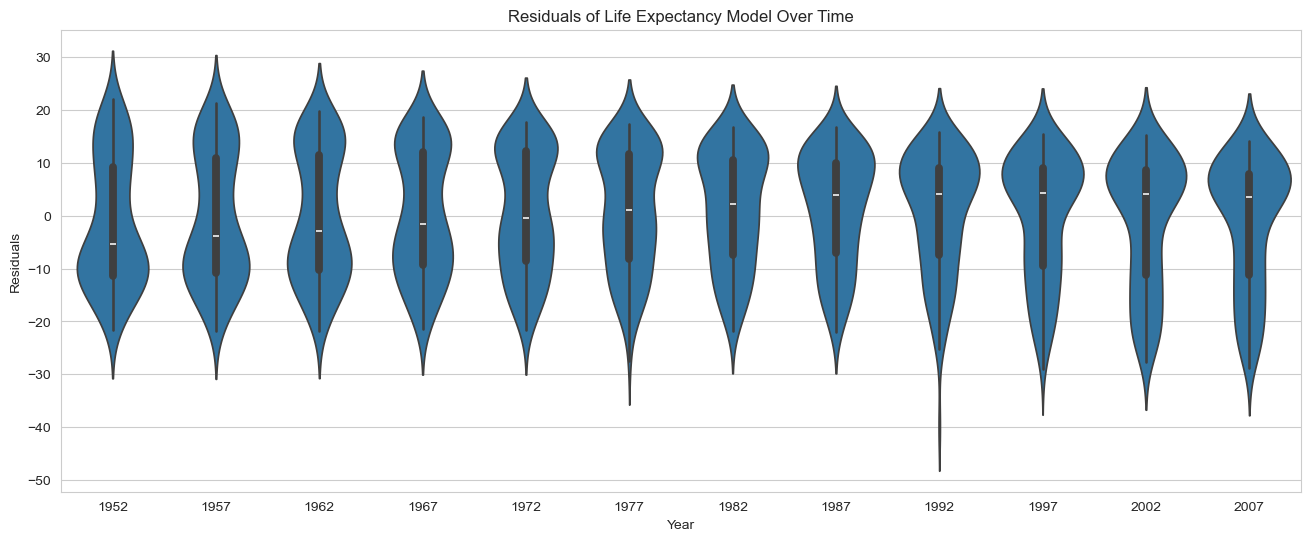

In [21]:

data['predicted_lifeExp'] = linear_model.predict(x)
data['residuals'] = data['lifeExp'] - data['predicted_lifeExp']


plt.figure(figsize=(16, 6))
sns.violinplot(x='year', y='residuals', data=data)
plt.title('Residuals of Life Expectancy Model Over Time')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.show()

**Question 8 Does the plot of Exercise 3 match your expectations (as you answered Question 4)?**

The scatter plot confirms the anticipated relationship between life expectancy and time. The linear regression line effectively captures the overall upward trajectory from 1960 to 2020, though with varying degrees of accuracy across different periods[1]. While some years show data points clustering tightly around the regression line, indicating good model fit, there are notable deviations in certain periods. The observations from 1977 and 1992, in particular, display greater dispersion from the predicted values, demonstrating that while the linear model successfully represents the long-term trend, it doesn't fully account for all temporal variations in life expectancy[1].pngy.

**Exercise 4: Boxplot of Model Residuals vs Continent**

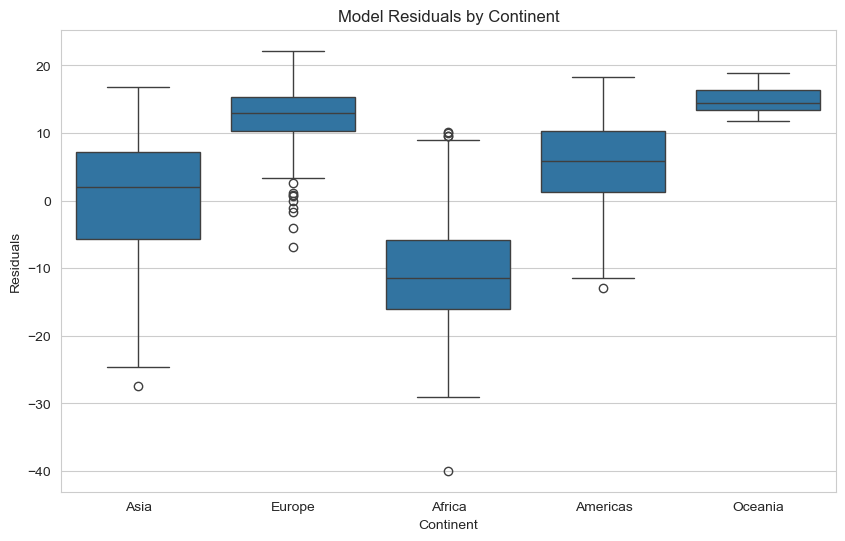

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='continent', y='residuals', data=data)
plt.title('Model Residuals by Continent')
plt.xlabel('Continent')
plt.ylabel('Residuals')
plt.show()

**Question 9 : Is there a dependence between model residual and continent? If so, what would that suggest when performing a regression analysis of life expectancy across time?**

The residual analysis reveals systematic differences in how well the linear model predicts life expectancy across continents. The pattern shows consistent underprediction for European countries and overprediction for African nations, highlighting regional variations in life expectancy trends. These systematic deviations suggest that the current model's effectiveness is limited by its simplicity. An enhanced regression model that incorporates continent as a predictor variable would likely provide more accurate predictions by accounting for these distinct regional patterns in life expectancy.

**Excercise 5: Scatter plot of Life Expectancy vs. Year, Grouped by Continent, and add a Regression Line.**

<Figure size 1600x600 with 0 Axes>

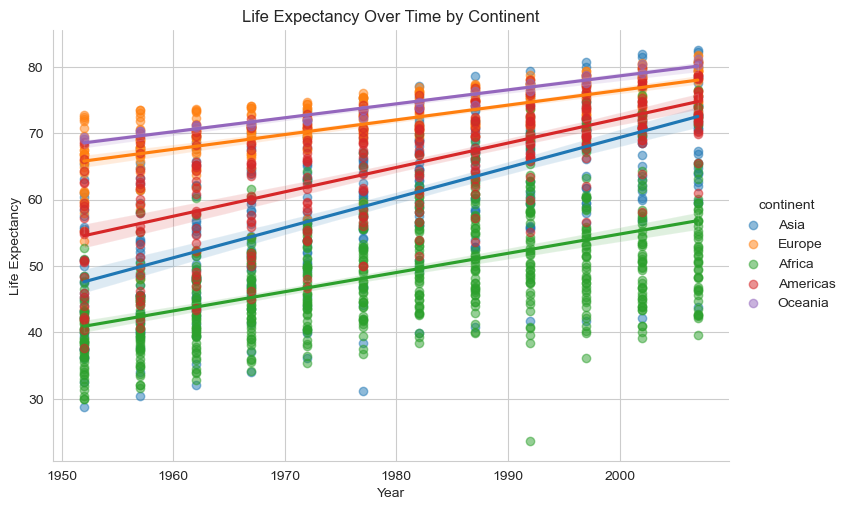

In [23]:
plt.figure(figsize=(16, 6))
sns.lmplot(x='year', y='lifeExp', hue='continent', data=data, aspect=1.5, markers="o", scatter_kws={'alpha':0.5})
plt.title('Life Expectancy Over Time by Continent')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.show()

**Question 10: Based on this plot, should your regression model include an interaction term for continent and year? Why?**

Yes, an interaction term between continent and year should be included.
The visualization indicates that continents exhibit distinct patterns in life expectancy growth over time. To accurately capture these varying regional trends, the model would improve by including an interaction term between continent and year. This addition would allow the model to reflect the unique rate of life expectancy improvement specific to each continent.

**Exercise 6: Fit a linear regression model for life expectancy including a term for an interaction between continent and year.**

In [24]:
import statsmodels.formula.api as smf

interaction_model = smf.ols('lifeExp ~ year * continent', data=data).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lifeExp   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     424.3
Date:                Wed, 06 Nov 2024   Prob (F-statistic):               0.00
Time:                        22:32:30   Log-Likelihood:                -5771.9
No. Observations:                1704   AIC:                         1.156e+04
Df Residuals:                    1694   BIC:                         1.162e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

**Question 11: Are All Parameters in the Model Significantly Different from Zero? If Not, Which Are Not Significantly Different from Zero?**

The statistical analysis reveals that not all model parameters demonstrate significance. Specifically, two parameters fail to meet the 0.05 significance threshold: Oceania (p = 0.287) and the interaction between year and Oceania (p = 0.360). Their p-values suggest that niether the effect of Oceania nor the interaction between year and Oceania on life expectancy significantly contribute to explaining variations in life expectancy in this model.

**Question 12: On average, by how much does life expectancy increase each year for each continent? (Provide code to answer this question by extracting relevant estimates from model fit).**

In [25]:
yearly_increase_base = interaction_model.params['year']

# Add interaction effects for each continent
# No interaction term for Africa, so we use the base effect

yi_americas = yearly_increase_base + interaction_model.params.get('year:continent[T.Americas]', 0)
yi_asia = yearly_increase_base + interaction_model.params.get('year:continent[T.Asia]', 0)
yi_europe = yearly_increase_base + interaction_model.params.get('year:continent[T.Europe]', 0)
yi_oceania = yearly_increase_base + interaction_model.params.get('year:continent[T.Oceania]', 0)
yi_africa = yearly_increase_base

print("Average yearly increase in life expectancy by continent:")
print(f"Africa: {yi_africa:.4f}")
print(f"Americas: {yi_americas:.4f}")
print(f"Asia: {yi_asia:.4f}")
print(f"Europe: {yi_europe:.4f}")
print(f"Oceania: {yi_oceania:.4f}")

Average yearly increase in life expectancy by continent:
Africa: 0.2895
Americas: 0.3677
Asia: 0.4531
Europe: 0.2219
Oceania: 0.2103


**Exercise 7: Perform an F-test that compares how well two models**

In [27]:

fvalue_simple = model.fvalue
pvalue_simple = model.f_pvalue

fvalue_interaction = interaction_model.fvalue
pvalue_interaction = interaction_model.f_pvalue

# Print results
print("Model with year only:")
print("F-value:", fvalue_simple)
print("p-value:", pvalue_simple)

print("\nModel with year and continent interaction:")
print("F-value:", fvalue_interaction)
print("p-value:", pvalue_interaction)

Model with year only:
F-value: 398.6047457117632
p-value: 7.546794625594231e-80

Model with year and continent interaction:
F-value: 424.27290234006944
p-value: 0.0


**Question 13: 
Is the interaction model significantly better than the year-only model? Why**?

The statistical evidence strongly supports the inclusion of the interaction term in the model. The interaction model demonstrates superior performance with an F-value of 424.27, compared to 398.60 for the year-only model. This higher F-value indicates that incorporating the interaction between year and continent provides a better explanation of variations in life expectancy.ce

The interaction model's p-value of zero definitively confirms its statistical significance. This means that the relationship between year and life expectancy varies meaningfully across different continents, rather than following a uniform pattern globally. The data reveals that the rate of life expectancy improvement over time is not consistent across all continents, making the interaction term an essential component of the model.

**Exercise 8: Make a residuals vs. year violin plot for the interaction model. Comment on how well it matches assumptions of the linear regression model. Do the same for a residuals vs. fitted values model.**

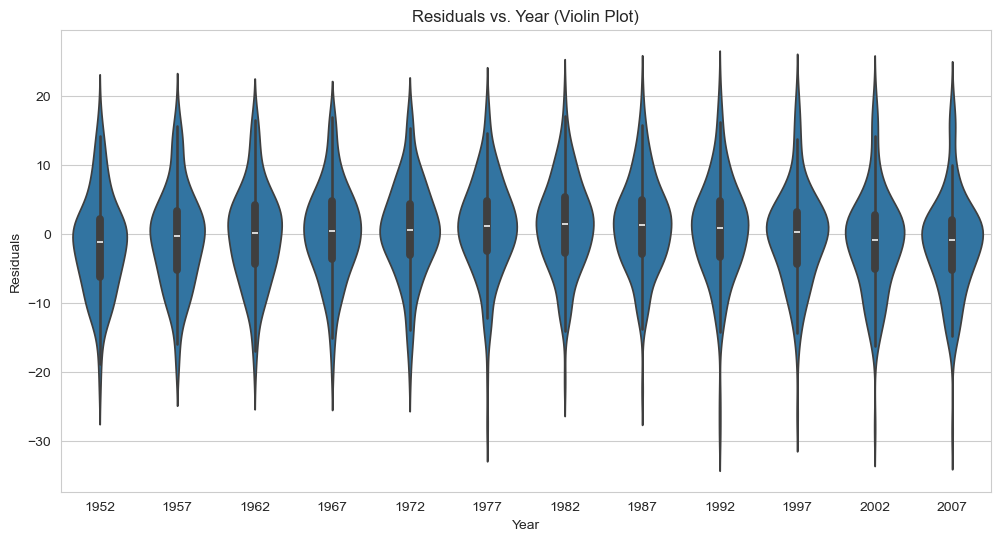

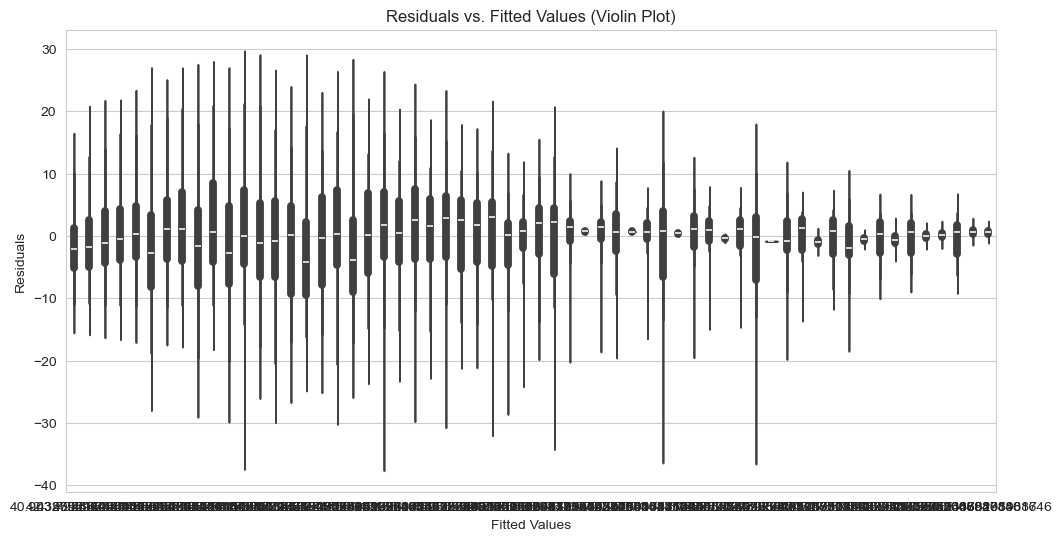

In [28]:
data['residuals'] = interaction_model.resid
data['fitted_values'] = interaction_model.fittedvalues

# Plot residuals vs. year using violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='year', y='residuals', data=data)
plt.title("Residuals vs. Year (Violin Plot)")
plt.xlabel("Year")
plt.ylabel("Residuals")
plt.show()

# Plot residuals vs. fitted values using violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='fitted_values', y='residuals', data=data)
plt.title("Residuals vs. Fitted Values (Violin Plot)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

Residuals vs. Year Violin Plot for the Interaction Model
Observations:
The residuals appear to be fairly symmetrically distributed around zero for each year, which is a good sign for the assumption of independence.
There is no obvious pattern or trend over time, suggesting that autocorrelation is not a significant issue.
The lack of a clear pattern indicates that the residuals are independent over time, which satisfies one of the key assumptions of linear regression.
The spread of residuals seems relatively consistent across different levels of fitted values, although there is some variability.
There is no clear funnel shape, which suggests that heteroscedasticity may not be a major issue.
Assumptions:
The consistent spread of residuals across fitted values suggests that the assumption of constant variance is reasonably met.

Linear Regression Model Observations:
The linear model also shows a similar pattern in residual distribution, but with potentially more variability due to the simpler model structure.